In [1]:
with open('names.txt', 'r') as file:
    names = file.read().splitlines()

names = [name.lower() for name in names]

In [2]:
chars = sorted(list(set(''.join(names))))

stoi = { ch:i+1 for i,ch in enumerate(chars) }
stoi['$'] = 0
itos = { i:ch for ch,i in stoi.items() }
vocab_size = len(stoi)
vocab_size


30

In [3]:
block_size = 3

In [4]:
import flashlight

def get_dataset(names):
  X = []
  Y = []
  for name in names:
      context = [0]*block_size
      for ch  in name + '$':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]
  X = flashlight.Tensor(X)
  Y = flashlight.Tensor(Y)
  return X,Y

In [5]:
def view_input_output(X, Y):
  for (context, output) in zip(X, Y):
    context_sequence = [itos[x] for x in context]
    out = itos[output]

In [6]:
import random
random.shuffle(names)

n1 = int(0.8*len(names))
n2 = int(0.9*len(names))

X_train, Y_train = get_dataset(names[:n1])
X_train._label = "X_train"; Y_train._label = "Y_train"
X_dev, Y_dev = get_dataset(names[n1:n2])
X_dev._label = "X_dev"; Y_dev._label = "Y_dev"
X_test, Y_test = get_dataset(names[n2:])
X_test._label = "X_test"; Y_test._label = "Y_test"

view_input_output(X_test[:2].numpy(), Y_test[:2].numpy())

In [7]:
X_train.shape, Y_train.shape

((405202, 3), (405202,))

In [8]:
embedding_size = 10
hidden_layers = 200

In [9]:
g = flashlight.Generator().manual_seed(2147483647)

In [10]:
C = flashlight.randn((vocab_size, embedding_size), generator=g); C._label = "C"
W1 = flashlight.randn((embedding_size * block_size, hidden_layers), generator=g); W1._label = "W1"

W2 = flashlight.randn(hidden_layers, vocab_size, generator=g); W2._label = "W2"
B2 = flashlight.randn(vocab_size, generator=g); B2._label = "B2"

bngain = flashlight.ones(1, hidden_layers); bngain._label = "bngain"
bnbias = flashlight.zeros(1, hidden_layers); bnbias._label = "bnbias"

In [11]:
W1.shape

(30, 200)

In [12]:
parameters = [C, W1, W2, B2, bngain, bnbias]
for p in parameters:
  p.requires_grad = True

In [13]:
number_of_parameters = sum(p.nelement() for p in parameters)
number_of_parameters

12730

In [14]:
X_train.shape, C.shape

((405202, 3), (30, 10))

In [15]:
def forward_pass(X, Y, bnmean_running, bnstd_running):
  emb = C[X]
  embcat = emb.view(emb.shape[0], -1)
  pass_through_hidden = embcat @ W1
  mean_hidden = pass_through_hidden.mean(0, keepdim=True)
  std_hidden = pass_through_hidden.std(0, keepdim=True)

  with flashlight.no_grad():
    bnmean_running = bnmean_running * 0.999 + mean_hidden * 0.001
    bnstd_running = bnstd_running * 0.999 + std_hidden * 0.001

  normalized = (pass_through_hidden - mean_hidden)/std_hidden
  apply_batch_nomalisation = bngain * normalized + bnbias
  non_linearity = flashlight.tanh(apply_batch_nomalisation)
  logits = non_linearity @ W2 + B2
  output_probs = flashlight.softmax(logits, dim=1)
  indices = flashlight.arange(output_probs.shape[0])
  likelihood = output_probs[indices, Y]
  log_likelihood = flashlight.log(likelihood)
  loss = -log_likelihood.mean()
  return {
    "loss": loss,
    "bnmean_running": bnmean_running,
    "bnstd_running": bnstd_running
  }

In [16]:
def forward_pass_batch(X, Y, bnmean_running, bnstd_running, batch_size=32):
  random_batch_indices = flashlight.randint(0, X_train.shape[0], (batch_size,), generator=g)
  X_batch = X[random_batch_indices]
  Y_batch = Y[random_batch_indices]
  result = forward_pass(X_batch, Y_batch, bnmean_running, bnstd_running)
  return result

In [17]:
def train(X, Y, epochs=50000, log_interval=1000, lr=0.01):
  bnmean_running = flashlight.zeros(1, hidden_layers)
  bnstd_running = flashlight.ones(1, hidden_layers)
  losses = []
  for epoch in range(epochs):
    result = forward_pass_batch(X, Y, bnmean_running, bnstd_running)
    batch_loss = result["loss"]
    bnmean_running = result["bnmean_running"]
    bnstd_running = result["bnstd_running"]
    losses.append((epoch, batch_loss.item()))

    for p in parameters:
      p.grad = None
    result["loss"].backward()

    for p in parameters:
      if p.grad is not None:
        p.data += -lr * p.grad.data
    if epoch % log_interval == 0:
      print(f"Epoch: {epoch}: Loss: {result['loss']}")
  final_loss = losses[epochs - 1]  
  return {
    "losses": losses,
    "final_loss": final_loss[1],
    "bnmean_running": bnmean_running,
    "bnstd_running": bnstd_running
  }

In [18]:
import importlib
importlib.reload(flashlight)

result = train(X_train, Y_train)
losses = result["losses"]
final_loss = result["final_loss"]
bnmean_running = result["bnmean_running"]
bnstd_running = result["bnstd_running"]
print('Final loss', final_loss)

Epoch: 0: Loss: Flashlight Tensor(data=16.912582397460938, shape=(), requires_grad=True)
Epoch: 1000: Loss: Flashlight Tensor(data=3.5900425910949707, shape=(), requires_grad=True)
Epoch: 2000: Loss: Flashlight Tensor(data=2.860806465148926, shape=(), requires_grad=True)
Epoch: 3000: Loss: Flashlight Tensor(data=2.8720755577087402, shape=(), requires_grad=True)
Epoch: 4000: Loss: Flashlight Tensor(data=2.0337319374084473, shape=(), requires_grad=True)
Epoch: 5000: Loss: Flashlight Tensor(data=2.3471109867095947, shape=(), requires_grad=True)
Epoch: 6000: Loss: Flashlight Tensor(data=2.4177334308624268, shape=(), requires_grad=True)
Epoch: 7000: Loss: Flashlight Tensor(data=2.110440969467163, shape=(), requires_grad=True)
Epoch: 8000: Loss: Flashlight Tensor(data=2.159104347229004, shape=(), requires_grad=True)
Epoch: 9000: Loss: Flashlight Tensor(data=2.8666250705718994, shape=(), requires_grad=True)
Epoch: 10000: Loss: Flashlight Tensor(data=2.427326202392578, shape=(), requires_grad=

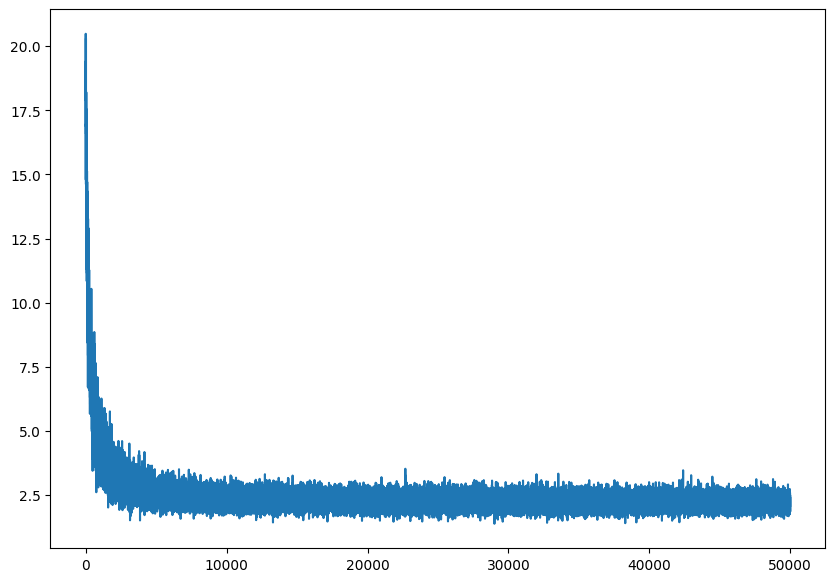

In [19]:
# Plot loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
plt.plot([x for x, _ in losses], [y for _, y in losses])
plt.show()

In [20]:
def validate(X, Y, bnmean_running, bnstd_running):
  emb = C[X]; emb._label = "embeddings"
  embcat = emb.view(emb.shape[0], -1); embcat._label = "embedding_cat"
  pass_through_hidden = embcat @ W1; pass_through_hidden._label = "pass_through_hidden"
  mean_hidden = pass_through_hidden.mean(0, keepdim=True); mean_hidden._label = "mean_hidden"
  std_hidden = pass_through_hidden.std(0, keepdim=True); std_hidden._label = "std_hidden"
  normalized_numerator = pass_through_hidden - mean_hidden; normalized_numerator._label = "normalized_numerator"
  normalized_denominator = std_hidden; normalized_denominator._label = "normalized_denominator"
  batch_normalisation = bngain * (normalized_numerator/normalized_denominator) + bnbias; batch_normalisation._label = "batch_normalisation"
  non_linearity = flashlight.tanh(batch_normalisation); non_linearity._label = "non_linearity"
  logits = non_linearity @ W2 + B2; logits._label = "logits"
  output_probs = flashlight.softmax(logits, dim=1); output_probs._label = "output_probs"
  indices = flashlight.arange(output_probs.shape[0]); indices._label = "indices"
  likelihood = output_probs[indices, Y]; likelihood._label = "likelihood"
  log_likelihood = flashlight.log(likelihood); log_likelihood._label = "log_likelihood"
  loss = -log_likelihood.mean(); loss._label = "loss"
  return loss

In [21]:
test_loss = validate(X_test, Y_test, bnmean_running, bnstd_running)
print('Test loss', test_loss)

Test loss Flashlight Tensor(data=2.1665663719177246, shape=(), requires_grad=True)


Validation loss Flashlight Tensor(data=2.16221022605896, shape=(), requires_grad=True)


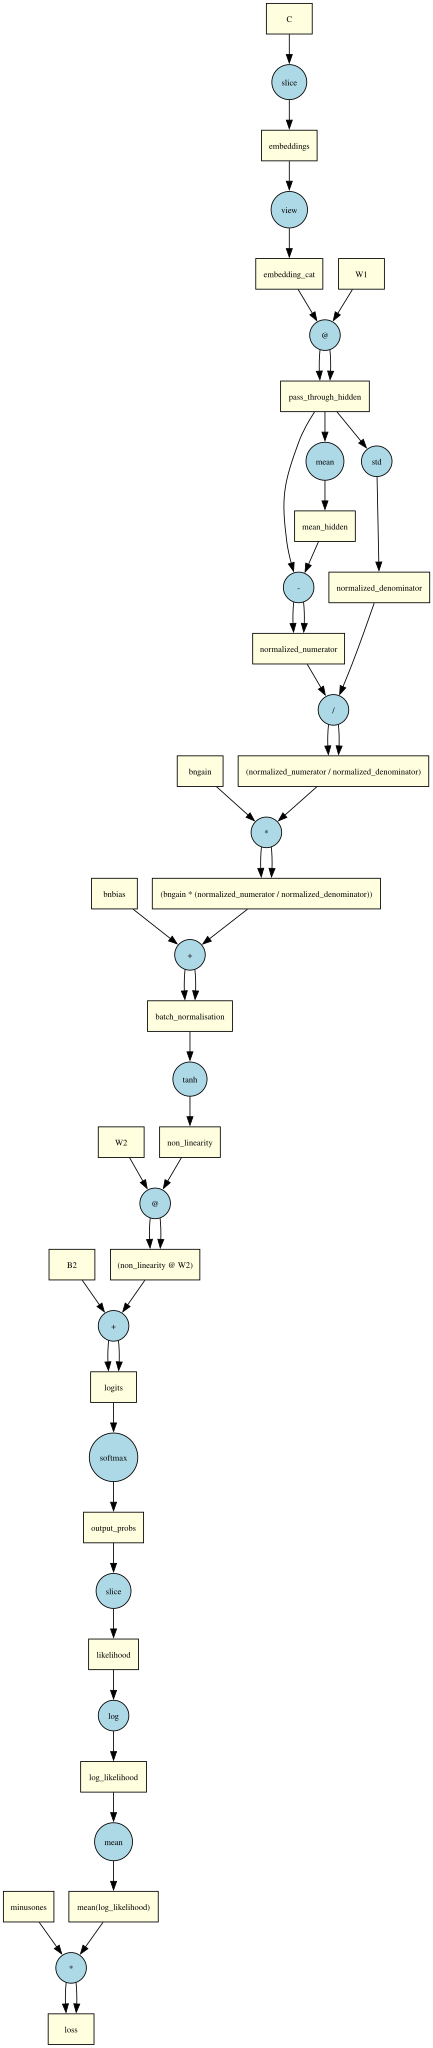

In [22]:
from flashlight import draw_dot
validation_loss = validate(X_dev, Y_dev, bnmean_running, bnstd_running)
print('Validation loss', validation_loss)
draw_dot(validation_loss, use_graphviz=True)

In [23]:
# Generate 200 names using the trained model above

names = []
for _ in range(200):
    out = []
    context = [0] * block_size
    while True:
        emb = C[flashlight.Tensor([context])]
        embcat = emb.view(1, -1)
        pass_through_hidden = embcat @ W1
        normalized = (pass_through_hidden - bnmean_running) / bnstd_running
        apply_batch_norm = bngain * normalized + bnbias
        h = flashlight.tanh(apply_batch_norm)
        logits = h @ W2 + B2
        probs = flashlight.softmax(logits, dim=1)
        ix = flashlight.multinomial(probs, num_samples=1).item()
        if ix == 0:
            break
        out.append(itos[ix])
        context = context[1:] + [ix]
    names.append(''.join(out))

for name in names:
    print(name)



araa
bikasan
gan
ad
nathuthkishkal
neleiya
zri
savedi
munundharuvdra
damathan
karan
ishitha
dabakurayievi
unuksvamalaara
hura
akidranzh
antuini
jamanan
mee
serathinish
shai
thasanan
siva
parkishin
ami
alo
parad
sweran
ara
yaran
charshwir
jeshukan
abhurun
livaprandhuven
midhinayaigamakevna
riya
ushandrarjari
bamisar
mewi
nesharsh
uaganagee
ksisni
aruthama
jar
nauy
nishei
peba
aishn
akrira
dina
ska
nagadevaki
nesherthan
kanyan
vathida
aran
haya
vakajaa
bashalivathasja
amaninichanthavirila
pilar
kamiliki
nika
man
maena
rakni
aran
siran
ceran
mana
byika
devarmi
naniyla
kumaran
alasesthadhan
saian
nirashasara
vava
narant yava
shana
soni
chunasan
pra
mauhuravanar
jee
ushvarathin
pisha
van
kayaswi
jumiransuna
vaesh
inaisavanosisha
paranpekiyanikyanin
karkiim
ana
san
davishila
par
rnithanashintkeva
hadirjasesunashani
fithan
voadka
arun
arula
rithinomimaran
yaviya
mavishrraklincranti
las
jamanikshinesi
anjashi
jrithran
ran
anshwranhunikannithibaiga
natrshili
beriraj
man
dhan
shinishpriyaka
vaat